In [ ]:
import Util.ExploratoryDataAnalysis
import Util.ModelDevelopment
from pathlib import Path
import pandas as pd
import os

In [34]:
# Get data into json file
#Util.ExploratoryDataAnalysis.bfs_battlelog_crawl("#8R8L082JJ", max_players=5, battles_per_player=5, out_path=os.path.join("test", "8R8L082JJ.json"))

Util.ExploratoryDataAnalysis.bfs_battlelog_crawl("#UG9QRV2RG", max_players=5000, battles_per_player=15, out_path=os.path.join("data", "UG9QRV2RG_12ktrophies_20260304.json"))

{'seed': '#UG9QRV2RG',
 'players_fetched': 5000,
 'edges_recorded': 376493,
 'out_path': 'data/UG9QRV2RG_12ktrophies_20260304.json'}

In [35]:
data_dir = Path("data")

dfs = [
    Util.ExploratoryDataAnalysis.load_battles_file_to_df(file)
    for file in data_dir.glob("*.json")
]

df = pd.concat(dfs, ignore_index=True)

df = pd.get_dummies(df, columns=['result'])

print(df.shape)
df.head()

(430591, 28)


,battleTime,gameModeId,playerTag,opponentTag,playerCrowns,opponentCrowns,crown_diff,p_card_1,o_card_1,p_card_2,...,o_card_6,p_card_7,o_card_7,p_card_8,o_card_8,p_card_9,o_card_9,result_draw,result_loss,result_win
0,20260303T044817.000Z,72000006,#9CVVPULRY,#9RRRV9PLP,1,0,1,26000007,26000017,26000011,...,26000004,26000021,26000043,28000007,28000011,159000000,159000000,0,0,1
1,20260303T040122.000Z,72000006,#9CVVPULRY,#2200YRUGGU,3,0,3,26000007,27000013,26000011,...,28000026,26000021,28000013,28000007,26000101,159000000,159000000,0,0,1
2,20260303T035814.000Z,72000006,#9CVVPULRY,#VYGPRCQLJ,0,1,-1,26000007,26000011,26000011,...,28000004,26000021,26000021,28000007,28000001,159000000,159000000,0,1,0
3,20260303T034754.000Z,72000006,#9CVVPULRY,#2LRLG2C28,1,0,1,26000007,26000064,26000011,...,26000048,26000021,28000003,28000007,26000042,159000000,159000000,0,0,1
4,20260303T034441.000Z,72000006,#9CVVPULRY,#8UJQQCQR,1,0,1,26000007,26000007,26000011,...,28000015,26000021,26000005,28000007,26000044,159000000,159000000,0,0,1


In [36]:
# Get the list of all the cards in the game from Clash Royale API
cards_df = Util.ExploratoryDataAnalysis.fetch_all_cards()

display(cards_df)

,name,id,maxLevel,maxEvolutionLevel,elixirCost,rarity,is_support
0,Knight,26000000,16,3.0,3.0,common,False
1,Archers,26000001,16,1.0,3.0,common,False
2,Goblins,26000002,16,2.0,2.0,common,False
3,Giant,26000003,14,2.0,5.0,rare,False
4,P.E.K.K.A,26000004,11,1.0,7.0,epic,False
...,...,...,...,...,...,...,...
120,Vines,28000026,11,NaN,3.0,epic,False
121,Tower Princess,159000000,16,NaN,NaN,common,True
122,Cannoneer,159000001,11,NaN,NaN,epic,True
123,Dagger Duchess,159000002,8,NaN,NaN,legendary,True


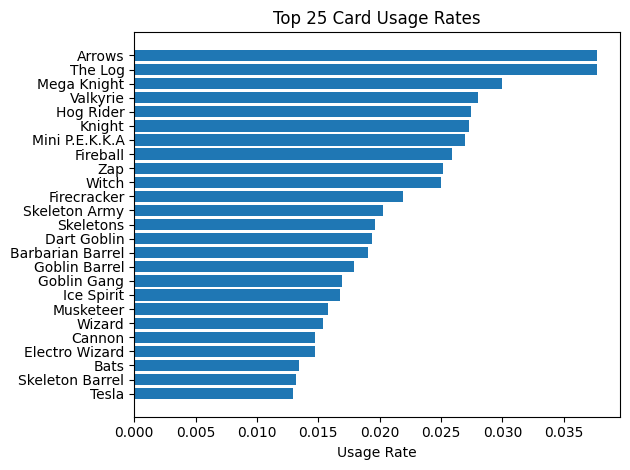

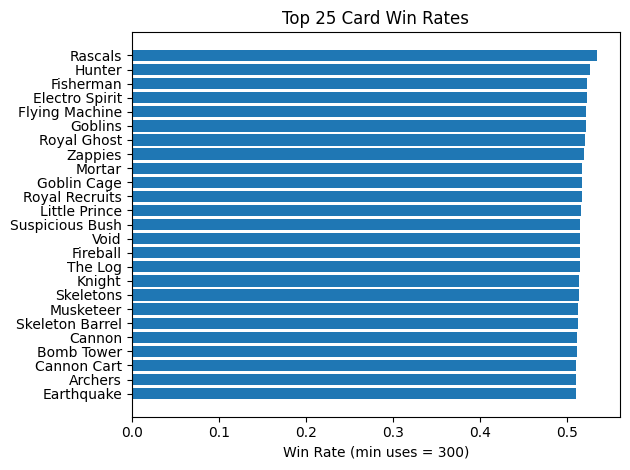

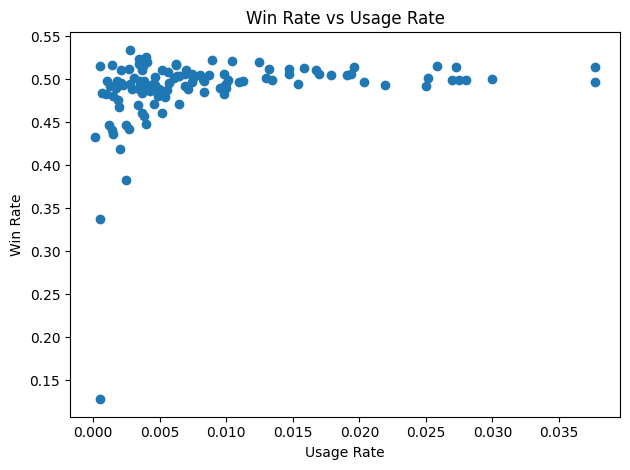

,card_id,usage_count,usage_rate,win_count,win_rate,name
0,28000001,259751,0.037703,129110,0.497053,Arrows
1,28000011,259726,0.037699,133692,0.514742,The Log
2,26000055,206495,0.029973,103232,0.499925,Mega Knight
3,26000011,192842,0.027991,96346,0.499611,Valkyrie
4,26000021,189310,0.027478,94581,0.499609,Hog Rider
5,26000000,187995,0.027287,96644,0.514078,Knight
6,26000018,185586,0.026938,92598,0.498949,Mini P.E.K.K.A
7,28000000,178156,0.025859,91816,0.515369,Fireball
8,28000008,173098,0.025125,86921,0.502149,Zap
9,26000007,172235,0.025000,84737,0.491985,Witch


In [37]:
card_stats = Util.ExploratoryDataAnalysis.plot_card_usage_and_win_rates(
    df,
    cards_df,
    top_n_usage=25,
    top_n_win=25,
    min_uses_for_winrate=300,
)

card_stats.head(25)

In [38]:
summary_stats = {
        "usage_rate_mean": card_stats["usage_rate"].mean(),
        "usage_rate_median": card_stats["usage_rate"].median(),
        "usage_rate_std": card_stats["usage_rate"].std(),
        "usage_rate_min": card_stats["usage_rate"].min(),
        "usage_rate_max": card_stats["usage_rate"].max(),

        "win_rate_mean": card_stats["win_rate"].mean(),
        "win_rate_median": card_stats["win_rate"].median(),
        "win_rate_std": card_stats["win_rate"].std(),
        "win_rate_min": card_stats["win_rate"].min(),
        "win_rate_max": card_stats["win_rate"].max(),

        "usage_count_mean": card_stats["usage_count"].mean(),
        "usage_count_median": card_stats["usage_count"].median(),
        "usage_count_std": card_stats["usage_count"].std(),
    }

summary_df = pd.DataFrame(summary_stats, index=["value"]).T

summary_df.head(15)

,value
usage_rate_mean,0.008264
usage_rate_median,0.005135
usage_rate_std,0.008032
usage_rate_min,0.000131
usage_rate_max,0.037703
win_rate_mean,0.489255
win_rate_median,0.496691
win_rate_std,0.042604
win_rate_min,0.127893
win_rate_max,0.534386
